# Sales Performance Dashboard

This notebook generates visualizations for the Sales Performance Dashboard task.
It loads `sales_data.csv`, processes the data, and creates the following plots:
1. Line graph: Monthly revenue trend.
2. Bar chart: Revenue comparison by country.
3. Histogram: Distribution of Quantity Ordered.
4. Scatter plot: Relationship between Unit Price and Revenue.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np

# Ensure plots are displayed inline in the notebook
%matplotlib inline

## Data Loading and Preparation

This function loads the data from the CSV file. If the file is missing or lacks required columns, it generates mock data for demonstration.

In [7]:
def load_and_prepare_data(filepath):
    """
    Loads data from CSV. If the file doesn't exist or doesn't have the expected columns,
    returns a mock DataFrame for demonstration.
    """
    expected_columns = ['Order Date', 'Country', 'Quantity Ordered', 'Unit Price']
    
    if os.path.exists(filepath):
        try:
            df = pd.read_csv(filepath)
            # Check if it has the columns we need (or similar ones we can map)
            # Common variations in Kaggle datasets:
            # 'Order Date' vs 'InvoiceDate'
            # 'Quantity Ordered' vs 'Quantity'
            # 'Unit Price' vs 'Price Each' vs 'UnitPrice'
            # 'Country' might be missing in some, but we need it.
            
            # Simple mapping attempt
            column_map = {
                'InvoiceDate': 'Order Date',
                'Quantity': 'Quantity Ordered',
                'Price Each': 'Unit Price',
                'UnitPrice': 'Unit Price',
                'Sales': 'Revenue' # If exists
            }
            df.rename(columns=column_map, inplace=True)
            
            if all(col in df.columns for col in expected_columns):
                print(f"Successfully loaded {filepath} with required columns.")
                return df
            else:
                print(f"File {filepath} exists but is missing required columns: {expected_columns}")
                print("Columns found:", df.columns.tolist())
                print("Using mock data for demonstration.")
        except Exception as e:
            print(f"Error reading {filepath}: {e}")
            print("Using mock data for demonstration.")
    else:
        print(f"File {filepath} not found. Using mock data for demonstration.")

    # Generate Mock Data
    dates = pd.date_range(start='2023-01-01', end='2023-12-31', freq='D')
    countries = ['USA', 'UK', 'Canada', 'Germany', 'France', 'Australia']
    
    np.random.seed(42)
    data = {
        'Order Date': np.random.choice(dates, size=1000),
        'Country': np.random.choice(countries, size=1000),
        'Quantity Ordered': np.random.randint(1, 20, size=1000),
        'Unit Price': np.random.uniform(10, 1000, size=1000)
    }
    df = pd.DataFrame(data)
    df.head()
    return df

## Data Processing

This function processes the data to ensure correct data types and calculate derived columns like 'Revenue' and 'Month'.

In [4]:
def process_data(df):
    # Ensure Date is datetime
    df['Order Date'] = pd.to_datetime(df['Order Date'])
    
    # Calculate Revenue if not exists
    if 'Revenue' not in df.columns:
        df['Revenue'] = df['Quantity Ordered'] * df['Unit Price']
        
    # Extract Month
    df['Month'] = df['Order Date'].dt.to_period('M')
    
    return df

## Visualizations

This function creates the requested visualizations.

In [5]:
def create_visualizations(df):
    # Set style
    plt.style.use('ggplot')
    
    # 1. Line graph: Monthly revenue trend
    monthly_revenue = df.groupby('Month')['Revenue'].sum()
    
    plt.figure(figsize=(10, 6))
    monthly_revenue.plot(kind='line', marker='o', color='b')
    plt.title('Monthly Revenue Trend')
    plt.xlabel('Month')
    plt.ylabel('Total Revenue ($)')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # 2. Bar chart: Revenue comparison by country
    country_revenue = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False)
    
    plt.figure(figsize=(10, 6))
    country_revenue.plot(kind='bar', color='green')
    plt.title('Revenue Comparison by Country')
    plt.xlabel('Country')
    plt.ylabel('Total Revenue ($)')
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()

    # 3. Histogram: Distribution of Quantity Ordered
    plt.figure(figsize=(10, 6))
    plt.hist(df['Quantity Ordered'], bins=20, color='orange', edgecolor='black')
    plt.title('Distribution of Quantity Ordered')
    plt.xlabel('Quantity Ordered')
    plt.ylabel('Frequency')
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()

    # 4. Scatter plot: Relationship between Unit Price and Revenue
    plt.figure(figsize=(10, 6))
    plt.scatter(df['Unit Price'], df['Revenue'], alpha=0.5, color='purple')
    plt.title('Relationship between Unit Price and Revenue')
    plt.xlabel('Unit Price ($)')
    plt.ylabel('Revenue ($)')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

## Execution

Run the following cell to execute the dashboard generation.

Starting Sales Performance Dashboard Task...
File sales_data.csv exists but is missing required columns: ['Order Date', 'Country', 'Quantity Ordered', 'Unit Price']
Columns found: ['product_id', 'product_name', 'category', 'discounted_price', 'actual_price', 'discount_percentage', 'rating', 'rating_count', 'about_product', 'user_id', 'user_name', 'review_id', 'review_title', 'review_content', 'img_link', 'product_link']
Using mock data for demonstration.


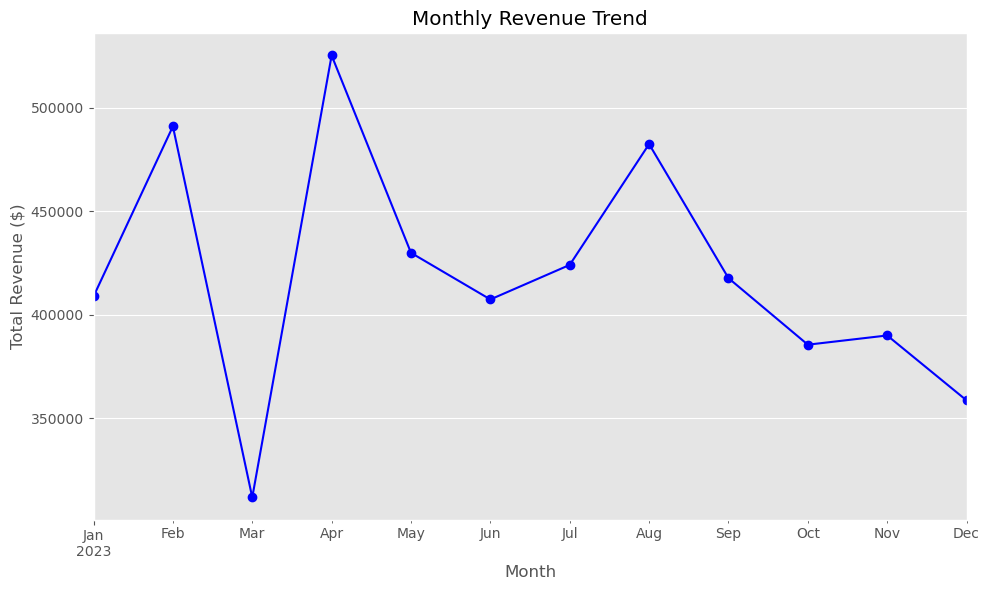

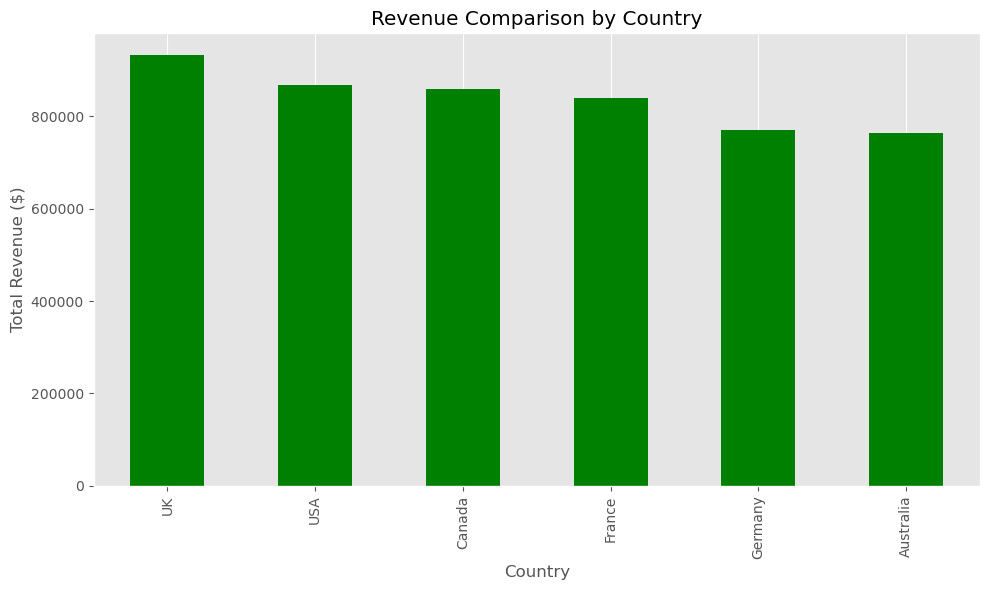

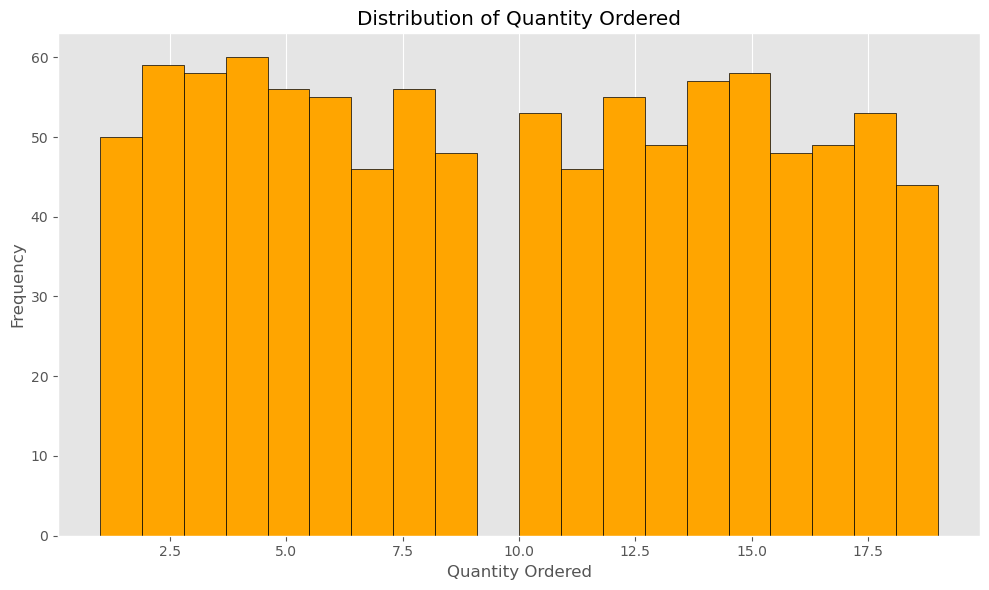

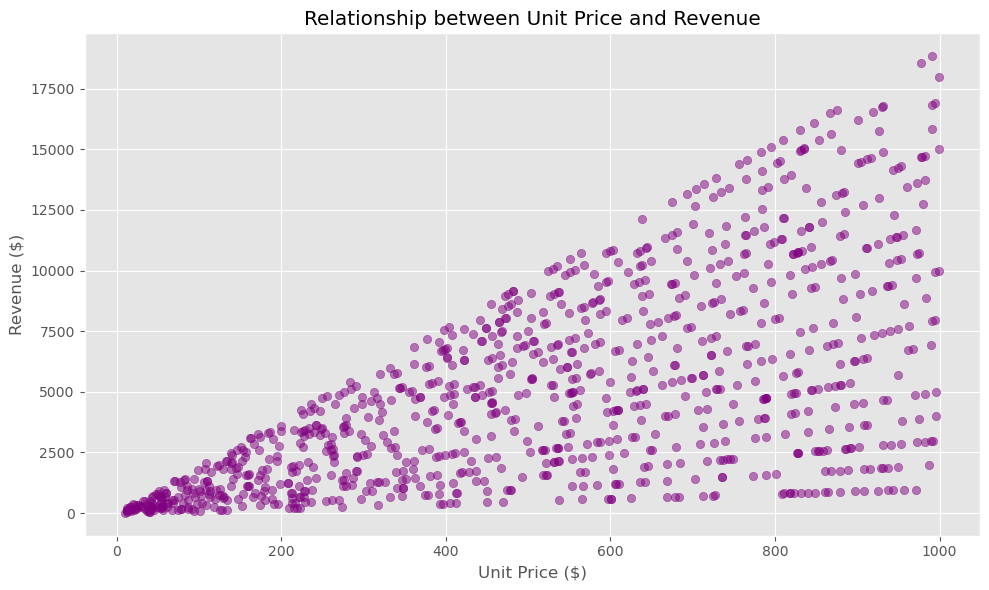

Task Complete.


In [6]:
# Path to your dataset
FILE_PATH = 'sales_data.csv'

print("Starting Sales Performance Dashboard Task...")
df = load_and_prepare_data(FILE_PATH)
df = process_data(df)
create_visualizations(df)
print("Task Complete.")